In [1]:
import pycountry
import pycountry_convert as pc

european_countries = []

for country in pycountry.countries:
    try:
        continent_code = pc.country_alpha2_to_continent_code(country.alpha_2)
        if continent_code == 'EU':
            european_countries.append(country)
    except KeyError:
        # some countries/territories aren't mapped
        continue


In [7]:
import warnings
warnings.filterwarnings('ignore')
from MisallocationAnalysis import MisallocationAnalysis
import joblib

start=2015
end=2024
for country in european_countries:
    try:
        country_analysis = MisallocationAnalysis(country.name, start=start, end=end)
        country_analysis.estimate_all_moments()
        joblib.dump(country_analysis, f'analysis_database/{country.name}{start}-{end}.joblib')
        print('Success', country.name, start, 'to', end)
    except:
        print('Fail',start, 'to', end, country.name)
        pass


Fail 2015 to 2024 Åland Islands
Fail 2015 to 2024 Albania
Fail 2015 to 2024 Andorra
Success Austria 2015 to 2024
Success Belgium 2015 to 2024
Success Bulgaria 2015 to 2024
Fail 2015 to 2024 Bosnia and Herzegovina
Fail 2015 to 2024 Belarus
Success Switzerland 2015 to 2024
Fail 2015 to 2024 Czechia
Success Germany 2015 to 2024
Fail 2015 to 2024 Denmark
Success Spain 2015 to 2024
Fail 2015 to 2024 Estonia
Success Finland 2015 to 2024
Success France 2015 to 2024
Fail 2015 to 2024 Faroe Islands
Fail 2015 to 2024 United Kingdom
Fail 2015 to 2024 Guernsey
Fail 2015 to 2024 Gibraltar
Fail 2015 to 2024 Greece
Success Croatia 2015 to 2024
Success Hungary 2015 to 2024
Fail 2015 to 2024 Isle of Man
Fail 2015 to 2024 Ireland
Fail 2015 to 2024 Iceland
Success Italy 2015 to 2024
Fail 2015 to 2024 Jersey
Fail 2015 to 2024 Liechtenstein
Fail 2015 to 2024 Lithuania
Fail 2015 to 2024 Luxembourg
Fail 2015 to 2024 Latvia
Fail 2015 to 2024 Monaco
Fail 2015 to 2024 Moldova, Republic of
Success North Macedoni

In [3]:


import os
import joblib

all_countries = {}
for dir in os.listdir('analysis_database'):
    country_analysis = joblib.load('analysis_database/'+dir)
    all_countries[dir.replace('.joblib', '')] = country_analysis 



In [4]:
import CompareCountries
import importlib
importlib.reload(CompareCountries)
from CompareCountries import CompareCountries

comparison = CompareCountries(all_countries.values())
compare_df = comparison.compare()

#only keep revenues above 30 percent and where both time periods are present
compare_df = compare_df[compare_df['Revenue Data Coverage %'] >= 20]
compare_df = compare_df[compare_df.groupby('Country')['Country'].transform('count') == 2]


In [5]:
compare_df.sort_values(['Country', 'Time']).reset_index(drop=True)

,Country,Time,Revenue Data Coverage %,Change Real Interest Rate %,Increase in Real Interest Rate %,Decrease in Real Interest Rate %,Change log MRPK %,Increase in MRPK %,Decrease in MRPK %,Coefficient of log_a on firm capital growth,P-Value Coefficient
0,Belgium,2000 - 2015,51.86,-2.65,7.15,-9.80,21.51,45.50,-23.99,0.037,0.000
1,Belgium,2015 - 2024,55.30,-1.62,10.32,-11.94,-8.36,33.94,-42.30,0.060,0.000
2,Bulgaria,2000 - 2015,48.79,-0.55,14.48,-15.03,9.02,58.20,-49.18,0.060,0.469
3,Bulgaria,2015 - 2024,69.40,-2.25,13.92,-16.17,-51.26,10.58,-61.84,0.059,0.000
4,Croatia,2000 - 2015,68.62,2.41,7.96,-5.55,28.92,57.31,-28.39,0.025,0.122
5,Croatia,2015 - 2024,72.70,-4.52,7.90,-12.42,2.17,14.45,-12.28,0.125,0.001
6,Hungary,2000 - 2015,32.07,4.48,15.05,-10.57,1543.10,1669.99,-126.89,0.095,0.608
7,Hungary,2015 - 2024,50.70,-0.53,12.29,-12.82,1.40,48.47,-47.07,0.044,0.060
8,Italy,2000 - 2015,38.12,-1.47,4.88,-6.35,-1.60,20.44,-22.04,-1.906,0.000
9,Italy,2015 - 2024,58.30,1.10,8.95,-7.85,-6.75,2.41,-9.16,0.020,0.000


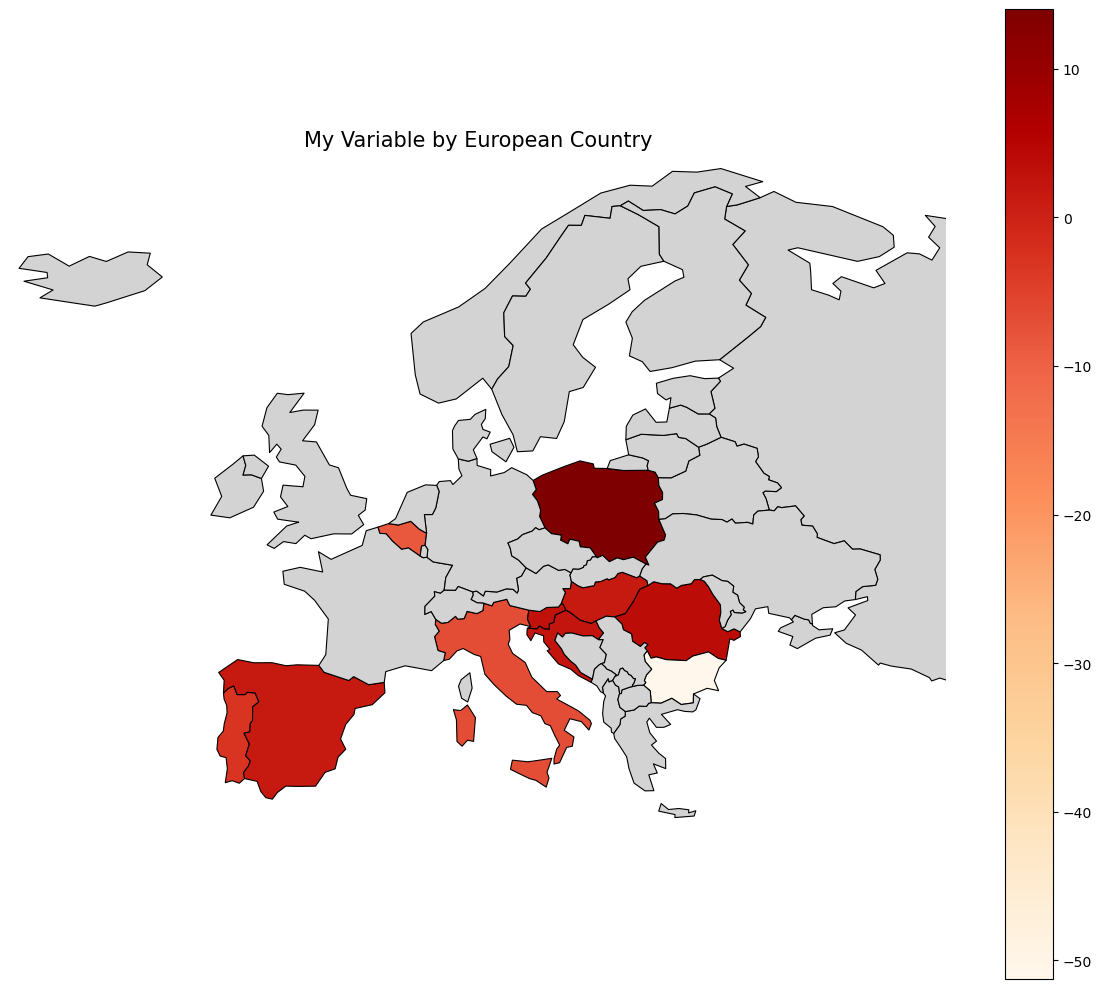

In [6]:
time = '2015 - 2024'
df = compare_df[compare_df['Time'] == time]
var = 'Change log MRPK %'


import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd


# ----------------------------
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Filter to Europe only
europe = world[world['CONTINENT'] == 'Europe']

# ----------------------------
# 3. Merge your data with the map (match on country name)
# ----------------------------
merged = europe.merge(df, how='left', left_on='SOVEREIGNT', right_on='Country')

# ----------------------------
# 4. Plot
# ----------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

merged.plot(
    column=var,
    cmap='OrRd',            # colormap - try 'viridis', 'coolwarm', 'Blues', etc.
    linewidth=0.8,
    edgecolor='black',
    legend=True,
    ax=ax,
    missing_kwds={
        'color': 'lightgrey',   # countries with no data
        'label': 'No data'
    }
)

ax.set_xlim(-25, 45)   # crop to European bounding box
ax.set_ylim(34, 72)
ax.set_title('My Variable by European Country', fontsize=15)
ax.axis('off')

plt.tight_layout()
plt.show()